In [ ]:
!pip -q install rosbags gdown
import sys, platform
print(sys.version)
print(platform.platform())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.9/144.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.1 MB/s eta 0:00:00
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Linux-6.6.122+-x86_64-with-glibc2.39


In [ ]:
exec("from pathlib import Path\nimport gdown, json, hashlib\nfrom rosbags.highlevel import AnyReader\nBAG = Path('/content/rotation_dataset.bag')\nif not BAG.exists():\n    gdown.download(id='1bwXvlEX0RYkixR3LDHte-U_KpMMIRG8x', output=str(BAG), quiet=False)\nassert BAG.exists() and BAG.stat().st_size > 1000000\nwith BAG.open('rb') as f:\n    assert f.read(13) == b'#ROSBAG V2.0\\n'\nprint('BAG bytes:', BAG.stat().st_size)\nwith AnyReader([BAG]) as reader:\n    print('Duration s:', reader.duration / 1e9)\n    for c in reader.connections:\n        print(c.topic, c.msgtype, c.msgcount)\n        if 'PointCloud2' in c.msgtype or 'Imu' in c.msgtype:\n            for cc, ts, raw in reader.messages(connections=[c]):\n                m = reader.deserialize(raw, cc.msgtype)\n                if 'PointCloud2' in c.msgtype:\n                    print('POINT FIELDS:', [(x.name,x.offset,x.datatype,x.count) for x in m.fields], 'point_step',m.point_step,'shape',m.height,m.width)\n                else:\n                    print('IMU first:',m)\n                break\n")

Downloading...
From (original): https://drive.google.com/uc?id=1bwXvlEX0RYkixR3LDHte-U_KpMMIRG8x
From (redirected): https://drive.google.com/uc?id=1bwXvlEX0RYkixR3LDHte-U_KpMMIRG8x&confirm=t&uuid=b1a07f89-ca4c-4831-8f49-012934e60591
To: /content/rotation_dataset.bag
100%|██████████| 352M/352M [00:04<00:00, 84.8MB/s]


BAG bytes: 352061920
Duration s: 58.632152202
/imu_correct sensor_msgs/msg/Imu 29316
IMU first: sensor_msgs__msg__Imu(header=std_msgs__msg__Header(seq=1287582, stamp=builtin_interfaces__msg__Time(sec=1574086536, nanosec=188852678, __msgtype__='builtin_interfaces/msg/Time'), frame_id='base_link', __msgtype__='std_msgs/msg/Header'), orientation=geometry_msgs__msg__Quaternion(x=-0.012573499847875879, y=0.040736396418770124, z=-0.26969219281158424, w=0.9620023774632096, __msgtype__='geometry_msgs/msg/Quaternion'), orientation_covariance=array([0.01, 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.01]), angular_velocity=geometry_msgs__msg__Vector3(x=0.08748125284910202, y=-0.22173960506916046, z=-0.5020036697387695, __msgtype__='geometry_msgs/msg/Vector3'), angular_velocity_covariance=array([0.01, 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.01]), linear_acceleration=geometry_msgs__msg__Vector3(x=-0.5011295144632459, y=-0.40116240933537484, z=10.069118192195893, __msgtype__='geometry_msgs/msg/Ve

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation, Slerp
from pathlib import Path
import hashlib, json, sys, importlib.metadata, time
OUT = Path('/content/t4_real_results'); OUT.mkdir(exist_ok=True)
log_lines = []
def log(s):
    print(s, flush=True); log_lines.append(str(s))
    (OUT/'run.log').write_text(chr(10).join(log_lines), encoding='utf-8')
def stamp(m):
    return m.header.stamp.sec + m.header.stamp.nanosec * 1e-9
imu_records=[]; scan_records=[]; inventory=[]
with AnyReader([BAG]) as reader:
    inventory=[dict(topic=c.topic,type=c.msgtype,count=c.msgcount) for c in reader.connections]
    imu_con=[c for c in reader.connections if c.topic=='/imu_correct']
    cloud_con=[c for c in reader.connections if c.topic=='/points_raw']
    assert len(imu_con)==1 and len(cloud_con)==1
    for c,ts,raw in reader.messages(connections=imu_con):
        m=reader.deserialize(raw,c.msgtype); q=m.orientation; w=m.angular_velocity
        imu_records.append([stamp(m),q.x,q.y,q.z,q.w,w.x,w.y,w.z])
    epoch=imu_records[0][0]
    cloud_inventory=[]
    for scan_id,(c,ts,raw) in enumerate(reader.messages(connections=cloud_con)):
        m=reader.deserialize(raw,c.msgtype); st=stamp(m)-epoch
        cloud_inventory.append([scan_id,st,m.width*m.height])
        if not (2 <= st <= 32):
            continue
        # Same deterministic subset for every condition, at most 3000 points/scan.
        fields={f.name:f for f in m.fields}
        assert all(n in fields for n in ['x','y','z','time','ring'])
        endian='>' if m.is_bigendian else '<'
        dtype=np.dtype({'names':['x','y','z','time','ring'],
          'formats':[endian+'f4']*4+[endian+'u2'],
          'offsets':[fields[n].offset for n in ['x','y','z','time','ring']],
          'itemsize':m.point_step})
        arr=np.ndarray((m.height,m.width),dtype=dtype,buffer=m.data,
                       strides=(m.row_step,m.point_step)).reshape(-1)
        xyz=np.column_stack([arr[n] for n in ['x','y','z']]).astype(float)
        rel=arr['time'].astype(float); radius=np.linalg.norm(xyz,axis=1)
        good=np.isfinite(xyz).all(axis=1)&np.isfinite(rel)&(radius>=2)&(radius<=30)&(rel>=0)&(rel<=.2)
        ids=np.flatnonzero(good)
        if len(ids)<100: continue
        ids=ids[np.linspace(0,len(ids)-1,min(3000,len(ids))).astype(int)]
        scan_records.append(dict(scan_id=scan_id,t=st,xyz=xyz[ids],rel=rel[ids]))
imu=np.array(imu_records); imu[:,0]-=epoch
assert np.all(np.diff(imu[:,0])>0), 'Non-monotonic IMU timestamps'
assert np.max(np.abs(np.linalg.norm(imu[:,1:5],axis=1)-1))<.02
slerp=Slerp(imu[:,0],Rotation.from_quat(imu[:,1:5]))
R0=slerp([scan_records[0]['t']])[0]
def omega_at(times):
    return np.column_stack([np.interp(times,imu[:,0],imu[:,j]) for j in [5,6,7]])
assert len(scan_records)>100
for s in scan_records:
    assert s['t']+s['rel'].min()-.2 >= imu[0,0]
    assert s['t']+s['rel'].max() <= imu[-1,0]
versions={p:importlib.metadata.version(p) for p in ['numpy','scipy','pandas','matplotlib','rosbags','gdown']}
config=dict(dataset='LIO-SAM rotation_dataset.bag',
 source_url='https://drive.google.com/file/d/1bwXvlEX0RYkixR3LDHte-U_KpMMIRG8x/view',
 dataset_bytes=BAG.stat().st_size,dataset_sha256=hashlib.file_digest(BAG.open('rb'),'sha256').hexdigest(),
 interval_s=[2,32],epoch_unix_s=epoch,offsets_ms=[0,50,100,150,200],
 min_range_m=2,max_range_m=30,max_points_per_scan=3000,scans=len(scan_records),
 points=sum(len(s['xyz']) for s in scan_records),versions=versions,python=sys.version,
 random_seed=None,extrinsic_rotation='identity per Rotation dataset README',
 compensation='constant body angular velocity extrapolation of stale IMU attitude',
 offset_convention='IMU header shifted +delta; query original attitude at t-delta',
 reference='same real LiDAR points transformed using zero-added-offset IMU attitude; internal proxy, NOT ground truth',
 omissions=['ego translation','lever arm','target motion','full LIO-SAM','independent ground truth'])
(OUT/'config.json').write_text(json.dumps(config,indent=2))
(OUT/'topics.json').write_text(json.dumps(inventory,indent=2))
pd.DataFrame(imu,columns=['t_s','qx','qy','qz','qw','wx_rad_s','wy_rad_s','wz_rad_s']).to_csv(OUT/'imu.csv',index=False)
pd.DataFrame(cloud_inventory,columns=['scan_id','t_s','raw_point_count']).to_csv(OUT/'scan_timeline.csv',index=False)
np.savez_compressed(OUT/'selected_real_points.npz',
 xyz=np.concatenate([s['xyz'] for s in scan_records]),
 point_time_s=np.concatenate([s['t']+s['rel'] for s in scan_records]),
 scan_id=np.concatenate([np.full(len(s['xyz']),s['scan_id']) for s in scan_records]))
log('DATA LOADED: '+json.dumps({k:config[k] for k in ['dataset_bytes','scans','points','interval_s']}))
log('IMU median rate Hz: '+str(1/np.median(np.diff(imu[:,0]))))
log('Point time range s: '+str([min(s['rel'].min() for s in scan_records),max(s['rel'].max() for s in scan_records)]))
print(pd.DataFrame(inventory).to_string(index=False))


DATA LOADED: {"dataset_bytes": 352061920, "scans": 298, "points": 894000, "interval_s": [2, 32]}
IMU median rate Hz: 967.9907685206555
Point time range s: [np.float64(0.0), np.float64(0.10092909634113312)]
       topic                        type  count
/imu_correct         sensor_msgs/msg/Imu  29316
 /points_raw sensor_msgs/msg/PointCloud2    582


In [ ]:
# PROXY benchmark on real observations; zero-offset IMU is NOT independent ground truth.
summary=[]; per_scan=[]; debug_examples={}
rmse=lambda x: float(np.sqrt(np.mean(np.square(x))))
log('PROTOCOL: paired point displacement versus zero-added-offset IMU reference, rotation only.')
for offset_ms in config['offsets_ms']:
    started=time.perf_counter(); delta=offset_ms/1000
    all_raw=[]; all_comp=[]; all_fixed=[]; all_pred=[]; all_deskew=[]
    for s in scan_records:
        pts=s['xyz']; tp=s['t']+s['rel']; stale=tp-delta
        R_ref=slerp(tp); R_stale=slerp(stale); w=omega_at(stale)
        # IMU angular velocity is expressed in its body frame; extrapolate on the right.
        R_pred=R_stale*Rotation.from_rotvec(w*delta)
        ref=R0.inv().apply(R_ref.apply(pts))
        raw=R0.inv().apply(R_stale.apply(pts))
        comp=R0.inv().apply(R_pred.apply(pts))
        fixed=R0.inv().apply(slerp(stale+delta).apply(pts))
        er=np.linalg.norm(raw-ref,axis=1); ec=np.linalg.norm(comp-ref,axis=1)
        ef=np.linalg.norm(fixed-ref,axis=1)
        ep=np.linalg.norm(np.cross(w,pts),axis=1)*delta
        # Separate sensitivity of within-scan rotational deskew (both times shifted).
        D_ref=(slerp([s['t']])[0].inv()*R_ref).apply(pts)
        D_shift=(slerp([s['t']-delta])[0].inv()*R_stale).apply(pts)
        ed=np.linalg.norm(D_shift-D_ref,axis=1)
        all_raw.append(er); all_comp.append(ec); all_fixed.append(ef); all_pred.append(ep); all_deskew.append(ed)
        row=dict(offset_ms=offset_ms,scan_id=s['scan_id'],t_s=s['t'],N=len(pts),
                 raw_proxy_rmse_m=rmse(er),comp_proxy_rmse_m=rmse(ec),
                 raw_p95_m=float(np.percentile(er,95)),comp_p95_m=float(np.percentile(ec,95)),
                 clock_fixed_proxy_rmse_m=rmse(ef),linear_prediction_rmse_m=rmse(ep),
                 within_scan_deskew_difference_rmse_m=rmse(ed))
        per_scan.append(row)
        if offset_ms==200 and (not debug_examples or row['raw_proxy_rmse_m']>debug_examples['rmse']):
            debug_examples=dict(rmse=row['raw_proxy_rmse_m'],scan_id=s['scan_id'],t_s=s['t'],ref=ref,raw=raw,comp=comp,er=er,ec=ec)
    er=np.concatenate(all_raw); ec=np.concatenate(all_comp); ef=np.concatenate(all_fixed)
    ep=np.concatenate(all_pred); ed=np.concatenate(all_deskew)
    result=dict(offset_ms=offset_ms,scans=len(scan_records),points=len(er),
                raw_proxy_rmse_m=rmse(er),comp_proxy_rmse_m=rmse(ec),
                raw_p95_m=float(np.percentile(er,95)),comp_p95_m=float(np.percentile(ec,95)),
                clock_fixed_proxy_rmse_m=rmse(ef),linear_prediction_rmse_m=rmse(ep),
                within_scan_deskew_difference_rmse_m=rmse(ed),
                raw_over_0p5m_pct=float(100*np.mean(er>.5)),comp_over_0p5m_pct=float(100*np.mean(ec>.5)),
                processing_seconds=time.perf_counter()-started)
    summary.append(result)
    pd.DataFrame(summary).to_csv(OUT/'metrics.csv',index=False)
    pd.DataFrame(per_scan).to_csv(OUT/'per_scan_metrics.csv',index=False)
    assert result['clock_fixed_proxy_rmse_m']<1e-8
    if offset_ms==0:
        assert result['raw_proxy_rmse_m']<1e-10 and result['comp_proxy_rmse_m']<1e-10
        log('BASELINE PASS before perturbation sweep')
    log('MEASURED '+json.dumps(result))
metrics=pd.DataFrame(summary); scans=pd.DataFrame(per_scan)
print(metrics.to_string(index=False))
log('DONE: same real points for all conditions. Clock-fixed zero is a construction sanity check.')
# Unshifted gyro / orientation consistency is logged, not used to tune the benchmark.
dt=np.diff(imu[:,0]); dq=Rotation.from_quat(imu[:-1,1:5]).inv()*Rotation.from_quat(imu[1:,1:5])
gyro_diff=dq.as_rotvec()/dt[:,None] - .5*(imu[:-1,5:8]+imu[1:,5:8])
log('IMU gyro-vs-quaternion derivative RMS rad/s: '+str(rmse(np.linalg.norm(gyro_diff,axis=1))))
np.savez_compressed(OUT/'failure_case_points.npz',**debug_examples)


PROTOCOL: paired point displacement versus zero-added-offset IMU reference, rotation only.
BASELINE PASS before perturbation sweep
MEASURED {"offset_ms": 0, "scans": 298, "points": 894000, "raw_proxy_rmse_m": 0.0, "comp_proxy_rmse_m": 8.374030672390143e-16, "raw_p95_m": 0.0, "comp_p95_m": 9.155133597044475e-16, "clock_fixed_proxy_rmse_m": 0.0, "linear_prediction_rmse_m": 0.0, "within_scan_deskew_difference_rmse_m": 0.0, "raw_over_0p5m_pct": 0.0, "comp_over_0p5m_pct": 0.0, "processing_seconds": 13.428618889000006}
MEASURED {"offset_ms": 50, "scans": 298, "points": 894000, "raw_proxy_rmse_m": 0.35363593966429546, "comp_proxy_rmse_m": 0.09160621314791421, "raw_p95_m": 0.6718949527227834, "comp_p95_m": 0.1819284456459933, "clock_fixed_proxy_rmse_m": 0.0, "linear_prediction_rmse_m": 0.35156093827879886, "within_scan_deskew_difference_rmse_m": 0.11328988778867843, "raw_over_0p5m_pct": 8.838255033557047, "comp_over_0p5m_pct": 0.29261744966442954, "processing_seconds": 9.342599800000016}
MEASU

In [ ]:
print('Runtime check:', sys.version)
print('Completed conditions:', len(globals().get('summary', [])))
print('Saved files:', sorted(p.name for p in OUT.glob('*')))


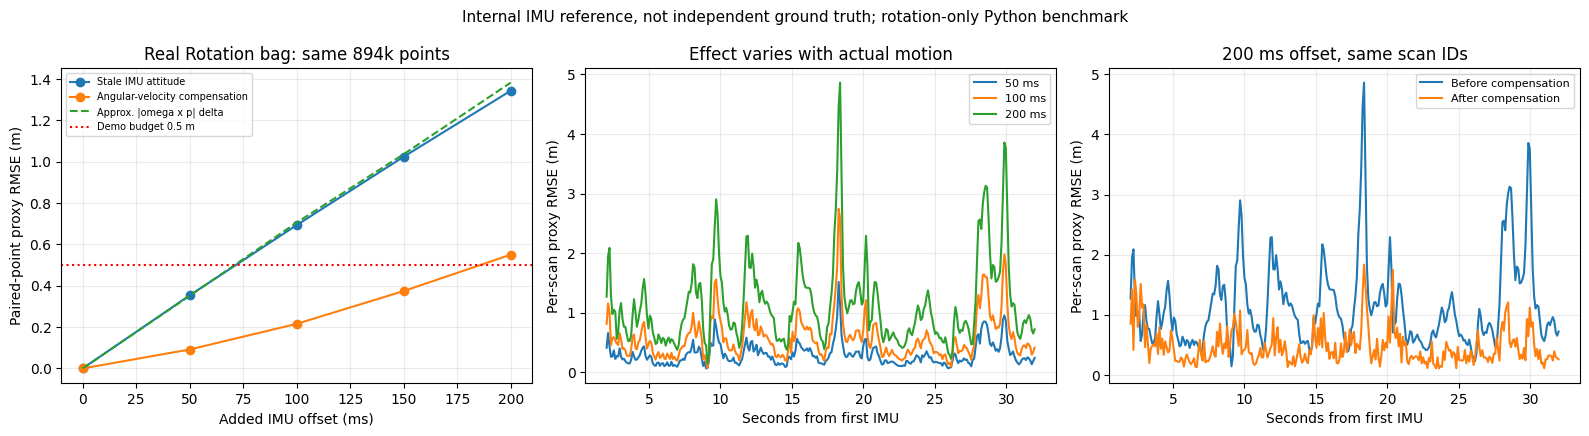

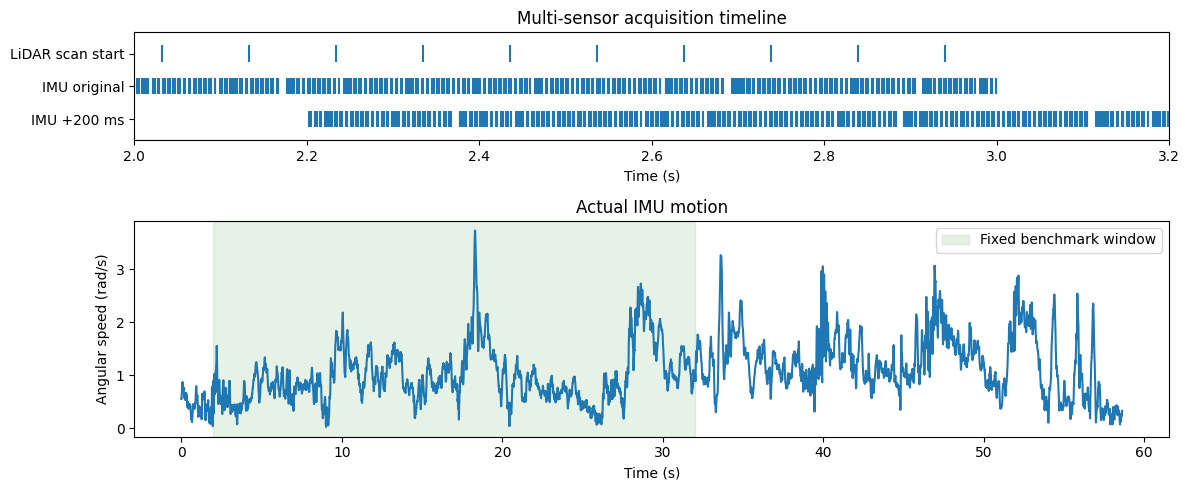

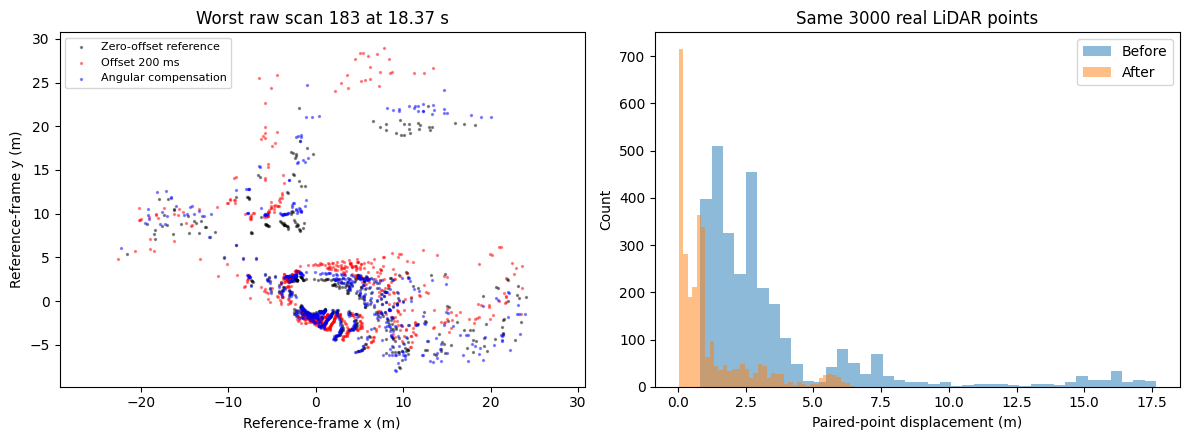

IMU effective mean rate Hz: 499.9992548566378
IMU interval p5/p50/p95 ms: [0.9360313415527344, 1.0330677032470703, 4.051923751831055]
 offset_ms  raw_proxy_rmse_m  comp_proxy_rmse_m  raw_p95_m   comp_p95_m
         0          0.000000       8.374031e-16   0.000000 9.155134e-16
        50          0.353636       9.160621e-02   0.671895 1.819284e-01
       100          0.693546       2.156904e-01   1.319804 4.362091e-01
       150          1.024446       3.745068e-01   1.944863 7.395359e-01
       200          1.343687       5.503635e-01   2.547933 1.119097e+00
PLOTS AND REPORT SAVED


In [ ]:
# Plot measured results and write a transparent interpretation.
fig,ax=plt.subplots(1,3,figsize=(16,4.4))
ax[0].plot(metrics.offset_ms,metrics.raw_proxy_rmse_m,'o-',label='Stale IMU attitude')
ax[0].plot(metrics.offset_ms,metrics.comp_proxy_rmse_m,'o-',label='Angular-velocity compensation')
ax[0].plot(metrics.offset_ms,metrics.linear_prediction_rmse_m,'--',label='Approx. |omega x p| delta')
ax[0].axhline(.5,color='r',ls=':',label='Demo budget 0.5 m')
ax[0].set(xlabel='Added IMU offset (ms)',ylabel='Paired-point proxy RMSE (m)',title='Real Rotation bag: same 894k points')
ax[0].legend(fontsize=7)
for offset in [50,100,200]:
    sub=scans[scans.offset_ms==offset]
    ax[1].plot(sub.t_s,sub.raw_proxy_rmse_m,label=f'{offset} ms')
ax[1].set(xlabel='Seconds from first IMU',ylabel='Per-scan proxy RMSE (m)',title='Effect varies with actual motion')
ax[1].legend(fontsize=8)
sub=scans[scans.offset_ms==200]
ax[2].plot(sub.t_s,sub.raw_proxy_rmse_m,label='Before compensation')
ax[2].plot(sub.t_s,sub.comp_proxy_rmse_m,label='After compensation')
ax[2].set(xlabel='Seconds from first IMU',ylabel='Per-scan proxy RMSE (m)',title='200 ms offset, same scan IDs')
ax[2].legend(fontsize=8)
for a in ax: a.grid(alpha=.25)
fig.suptitle('Internal IMU reference, not independent ground truth; rotation-only Python benchmark',fontsize=11)
fig.tight_layout();fig.savefig(OUT/'offset_results.png',dpi=180);plt.show()
fig,ax=plt.subplots(2,1,figsize=(12,5),gridspec_kw={'height_ratios':[1,2]})
ct=np.array(cloud_inventory)[:,1]; sel=(ct>=2)&(ct<=3)
it=imu[:,0]; m=(it>=2)&(it<=3)
ax[0].eventplot([ct[sel],it[m],it[m]+.2],lineoffsets=[2,1,0],linelengths=.5)
ax[0].set(yticks=[0,1,2],yticklabels=['IMU +200 ms','IMU original','LiDAR scan start'],xlim=(2,3.2),xlabel='Time (s)',title='Multi-sensor acquisition timeline')
ax[1].plot(imu[:,0],np.linalg.norm(imu[:,5:8],axis=1))
ax[1].axvspan(2,32,alpha=.1,color='g',label='Fixed benchmark window')
ax[1].set(xlabel='Time (s)',ylabel='Angular speed (rad/s)',title='Actual IMU motion');ax[1].legend()
fig.tight_layout();fig.savefig(OUT/'sensor_timeline.png',dpi=180);plt.show()
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
f=debug_examples
for points,label,color in [(f['ref'],'Zero-offset reference','black'),(f['raw'],'Offset 200 ms','red'),(f['comp'],'Angular compensation','blue')]:
    ax[0].scatter(points[::5,0],points[::5,1],s=2,label=label,c=color,alpha=.4)
ax[0].set(xlabel='Reference-frame x (m)',ylabel='Reference-frame y (m)',title=f"Worst raw scan {f['scan_id']} at {f['t_s']:.2f} s")
ax[0].axis('equal');ax[0].legend(fontsize=8)
ax[1].hist(f['er'],bins=40,alpha=.5,label='Before');ax[1].hist(f['ec'],bins=40,alpha=.5,label='After')
ax[1].set(xlabel='Paired-point displacement (m)',ylabel='Count',title='Same 3000 real LiDAR points');ax[1].legend()
fig.tight_layout();fig.savefig(OUT/'failure_case.png',dpi=180);plt.show()
imu_span=imu[-1,0]-imu[0,0]
log('IMU effective mean rate Hz: '+str((len(imu)-1)/imu_span))
log('IMU interval p5/p50/p95 ms: '+str(np.percentile(np.diff(imu[:,0])*1000,[5,50,95]).tolist()))
worst_after=scans[scans.offset_ms==200].sort_values('comp_proxy_rmse_m',ascending=False).iloc[0].to_dict()
(OUT/'worst_compensated_scan.json').write_text(json.dumps(worst_after,indent=2))
report = '''# T4 - Colab benchmark on real Rotation bag

Executed in Google Colab using real LiDAR and IMU measurements. This is custom Python processing, not a run of the full LIO-SAM estimator.

## Protocol and interpretation
- Same 30-second interval [2,32] seconds, 298 scans, 3000 deterministic points per scan, ranges 2-30 m.
- IMU attitude is interpolated using quaternion SLERP; gyro is linearly interpolated. Rotation extrinsic is identity according to this dataset's README.
- Injected positive IMU timestamp offset delta is implemented by querying the original stream at t-delta.
- Reference point: R0^-1 R(t) p. Corrupted point: R0^-1 R(t-delta) p.
- Compensated point: R0^-1 R(t-delta) Exp(omega(t-delta)*delta) p.
- Metric: sqrt(mean(||p_condition-p_reference||^2)) in metres, identical point correspondences. P95 and fraction over 0.5 m also reported. Lower is better relative agreement.
- THIS IS AN INTERNAL PROXY. The zero-added-offset IMU reference is not independent ground truth. A baseline of zero and exact clock-correction zero are construction checks, not proof of absolute accuracy.
- A separate column reports the difference in within-scan deskew, which shifts both scan-start and point timestamps. It must not be confused with the common-reference displacement metric.
- Translation, IMU-LiDAR lever arm and independently moving targets are omitted. No camera/radar, detector metric, trajectory ATE or full SLAM was run.
- Approximation for rotation uses apparent point speed ||omega cross p||, not an invented vehicle speed. Motion variability and gyro/attitude inconsistency limit constant-angular-velocity extrapolation.
- The 0.5 m budget is a chosen demonstration threshold, not an automotive safety specification.

## Sources
Paper: https://arxiv.org/abs/2007.00258
Repo/dataset instructions: https://github.com/TixiaoShan/LIO-SAM#sample-datasets
Bag: https://drive.google.com/file/d/1bwXvlEX0RYkixR3LDHte-U_KpMMIRG8x/view
Bag SHA256 and package versions are in config.json. No LIO-SAM binary/commit was executed.

## Evidence
metrics.csv, per_scan_metrics.csv, config.json, topics.json, imu.csv, scan_timeline.csv, selected_real_points.npz, failure_case_points.npz, run.log, and PNG plots.
'''
report+='\n## Measured results\n\n'+metrics.to_markdown(index=False)+'\n\nWorst compensated scan at 200 ms:\n'+json.dumps(worst_after,indent=2)+'\n'
(OUT/'REPORT.md').write_text(report,encoding='utf-8')
print(metrics[['offset_ms','raw_proxy_rmse_m','comp_proxy_rmse_m','raw_p95_m','comp_p95_m']].to_string(index=False))
log('PLOTS AND REPORT SAVED')
